In [1]:
import QsamplingFromLogical as qfl

import numpy as np
import qiskit as qis

from qiskit.quantum_info.operators.random import * 
from qiskit_aer import AerSimulator
from qiskit.quantum_info import *

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram, plot_bloch_multivector

from matplotlib.pyplot import figure
import itertools


Qubit Mapping: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'anc1': 4, 'anc2': 5, 'anc3': 6, 'anc4': 7, 'anc5': 8}
The variable qubits: {'D', 'B', 'C', 'A'}


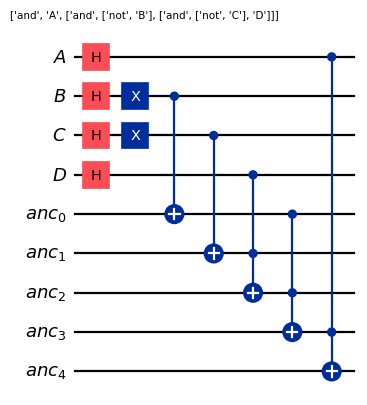

In [2]:
# Example Logical Expression
formula = ['and', 'A',['and',['not', 'B'],['and',['not', 'C'],'D']]]

# Generate Quantum Circuit with Dynamic Qubit Allocation
qc, qubits_map = qfl.logicaltoquantum(formula)
print("Qubit Mapping:", qubits_map)

# Recover variable qubits for late calculations
variable_qubits = qfl.extractvariables(formula)
print("The variable qubits:", variable_qubits)

fig = figure()
ax = fig.add_subplot()

ax.set_title(formula, fontsize=7.5, loc = 'left')

qc.draw('mpl', ax = ax)  # Draw the circuit

In [3]:
# Calculate the probability of 'target' state, and with it the rewuired rounds of amplification
rounds, good_state_prob = qfl.amplification_rounds(formula, variable_qubits)
print("The probability of obtaining the good state is: P =", good_state_prob)
print("Thus the number of rotations needed for near perfect amplification is: k =", rounds)

The probability of obtaining the good state is: P = 0.0625
Thus the number of rotations needed for near perfect amplification is: k = 3


In [4]:
# Generate the amplified circuits via the built in circuit composer, results in a dictionary of circuits, where the keys are the round of the amlification itself
amplified_circuits = qfl.generate_amplified_circuits(qc, qfl.oracle_generate(qc, good_state_prob), 
                                                 qfl.diffusion_generate(qc), rounds)

In [5]:
# make a copy so original isn't modified with measurements and can be utilized later on
amplified_circuits_copy = amplified_circuits.copy()
amplified_circuits_copy

{0: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x1a623ca9f10>,
 1: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x1a62403c580>,
 2: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x1a62403c730>,
 3: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x1a62403caf0>}

In [6]:
sim = AerSimulator(method="matrix_product_state")
N_shots = 1000000  # number of measurements

circuit_measurements = {}
prob_values = {}
counts = {}
res = {}

for i, circ in amplified_circuits_copy.items():
    # add 1 classical bit to measure last qubit
    creg = qis.ClassicalRegister(1)
    amplified_circuits_copy[i].add_register(creg)
    amplified_circuits_copy[i].measure(amplified_circuits_copy[i].num_qubits - 1, 0)

    # transpile
    circuit_measurements[i] = qis.transpile(amplified_circuits_copy[i], sim)

    # run simulation
    res[i] = sim.run(circuit_measurements[i], shots=N_shots, max_parallel_threads=16).result()
    counts[i] = res[i].get_counts()

    # normalize into probabilities
    prob_values[i] = {bit: count / N_shots for bit, count in counts[i].items()}


In [7]:
prob_values
# Also stored in a dict, where the keys are the possible states, |0>, or |1>

{0: {'0': 0.937569, '1': 0.062431},
 1: {'0': 0.527372, '1': 0.472628},
 2: {'1': 0.908645, '0': 0.091355},
 3: {'1': 0.961302, '0': 0.038698}}

## 2 different type of bar charts to see the amplification results

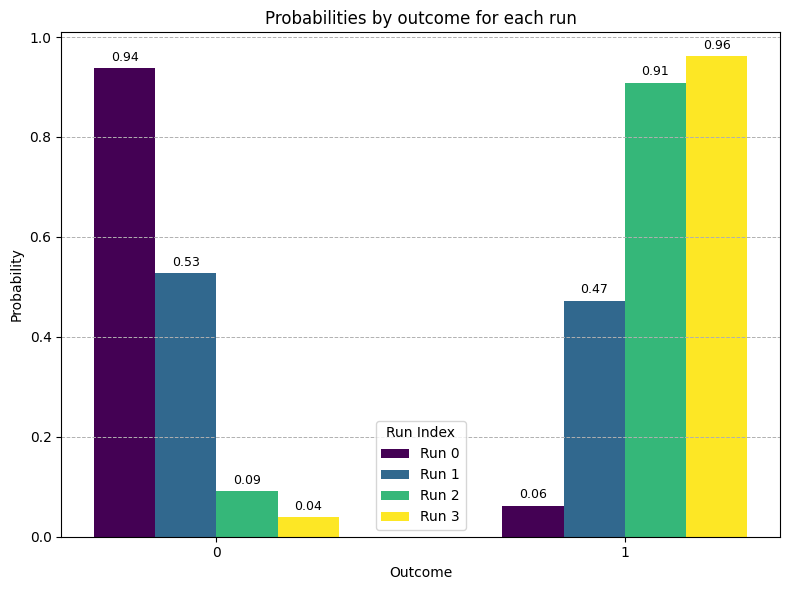

In [8]:
outcomes = ['0', '1']
runs = sorted(prob_values.keys())
num_runs = len(runs)
width = 0.15

x = np.arange(len(outcomes))

# Choose a color palette
colors = plt.cm.viridis(np.linspace(0, 1, num_runs))

fig, ax = plt.subplots(figsize=(8, 6))

bars = []
for idx, run in enumerate(runs):
    bar_values = [prob_values[run].get(o, 0) for o in outcomes]
    b = ax.bar(x + width*idx - width*num_runs/2 + width/2, bar_values, width, label=f'Run {run}', color=colors[idx])
    bars.append(b)

# Add bar labels
for b in bars:
    for rect in b:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),   # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(outcomes)
ax.set_xlabel('Outcome')
ax.set_ylabel('Probability')
ax.set_title('Probabilities by outcome for each run')
ax.grid(axis='y', linestyle='--', linewidth=0.7)
ax.legend(title='Run Index')

plt.tight_layout()
plt.show()


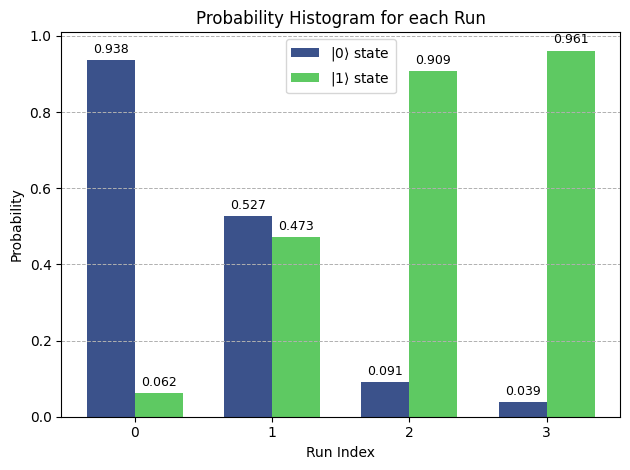

In [9]:
import matplotlib.pyplot as plt
import numpy as np

labels = sorted(prob_values.keys())  # run indices
x = np.arange(len(labels))           # x positions

probs_0 = [prob_values[i].get('0', 0) for i in labels]
probs_1 = [prob_values[i].get('1', 0) for i in labels]

width = 0.35

# Use continuous colormap for the two bar sets
colors = plt.cm.viridis(np.linspace(0.25, 0.75, 2))

fig, ax = plt.subplots()
rects0 = ax.bar(x - width/2, probs_0, width, label = r'$|0\rangle$ state', color=colors[0])
rects1 = ax.bar(x + width/2, probs_1, width, label = r'$|1\rangle$ state', color=colors[1])

# Add bar labels
for rect in rects0:
    height = rect.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Run Index')
ax.set_ylabel('Probability')
ax.set_title('Probability Histogram for each Run')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add grid mesh lines on y axis for readability
ax.grid(axis='y', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()


### Added plot to show the change in angle during the procedure in the Bloch-sphere reresentation. We work in a 2 dimensional slice of our state space, spanned by the $\ket{bad}$ and $\ket{good}$ registers. 

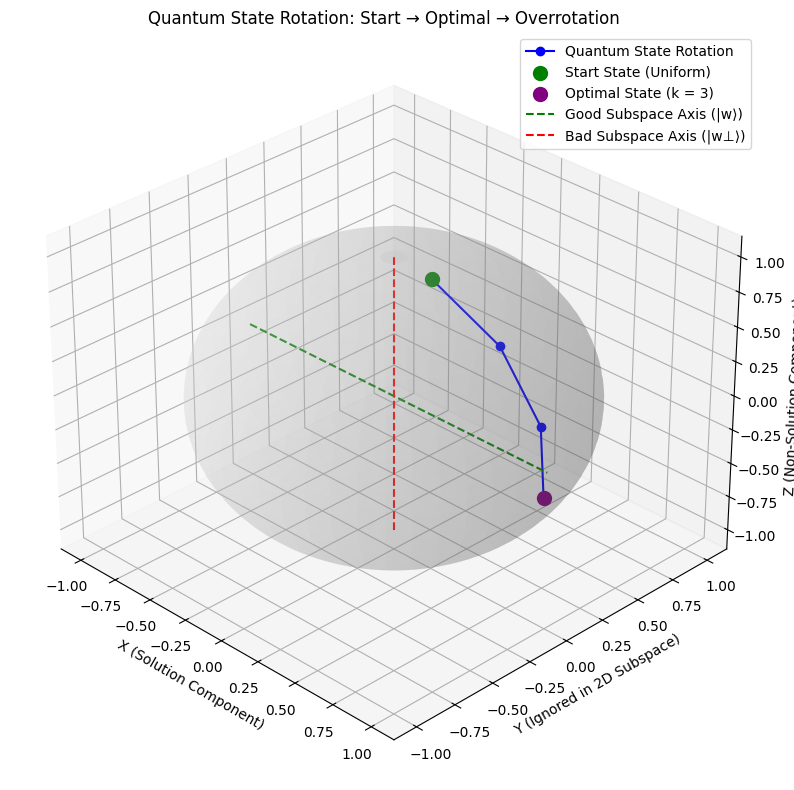

In [10]:
# Parameters
p0 = good_state_prob
k_opt = int(np.floor(np.pi / 4 * np.sqrt(1 / p0)))  # Optimal number of Grover iterations

# Define extended range of Grover iterations to show overrotation
k_values = np.arange(0, k_opt + 1)

# Calculate the changes in angle defined by the graphical description of the AA. procedure
theta_0 = np.arcsin(np.sqrt(p0))
theta_k = (2 * k_values + 1) * theta_0

# Compute Bloch coordinates
X = np.sin(theta_k)             # Projection onto X-axis (solution)
Y = np.zeros_like(X)            # Y-axis ignored in 2D Grover space
Z = np.cos(theta_k)             # Projection onto Z-axis (non-solution)

# Create 3D Bloch sphere
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# Plot Bloch sphere surface
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 50)
X_sphere = np.outer(np.cos(u), np.sin(v))
Y_sphere = np.outer(np.sin(u), np.sin(v))
Z_sphere = np.outer(np.ones_like(u), np.cos(v))
ax.plot_surface(X_sphere, Y_sphere, Z_sphere, color="lightgray", alpha=0.2)

# Plot the Grover rotation path
ax.plot(X, Y, Z, "bo-", label="Quantum State Rotation")
ax.scatter(X[0], Y[0], Z[0], color="green", s=100, label="Start State (Uniform)")
ax.scatter(X[k_opt], Y[k_opt], Z[k_opt], color="purple", s=100, label=f"Optimal State (k = {k_opt})")
#ax.scatter(X[-1], Y[-1], Z[-1], color="red", s=100, label="Overrotated State")

# Axes for solution and non-solution directions
ax.plot([-1, 1], [0, 0], [0, 0], "g--", linewidth=1.5, label="Good Subspace Axis (|w⟩)")
ax.plot([0, 0], [0, 0], [-1, 1], "r--", linewidth=1.5, label="Bad Subspace Axis (|w⊥⟩)")

# Labels and appearance
ax.set_xlabel("X (Solution Component)")
ax.set_ylabel("Y (Ignored in 2D Subspace)")
ax.set_zlabel("Z (Non-Solution Component)")
ax.set_title("Quantum State Rotation: Start → Optimal → Overrotation")
ax.view_init(elev=30, azim=-45)
ax.legend()

plt.tight_layout()
plt.show()
